# **Treniranje dva binarna modela za autentifikaciju tipkanjem**

---

Notebook trenira dva odvojena binarna modela:
- `jure_model.pkl` -> provjerava je li korisnik koji tipka Jure
- `mateo_model.pkl` -> provjerava je li korisnik koji tipka Mateo

Svaki model treniran je kao binarni klasifikator koji prepoznaje samo jednog korisnika. Pri treniranju Jurinog modela uzorcima tog korisnika dodijeljena je oznaka 1, a svim ostalim uzorcima oznaka 0. Na isti način treniran je i Mateov model

Svaki put kada korisnik započne sesiju, koristi se isključivo model koji odgovara prijavljenom korisniku (Jure ili Mateo)

---

## 1. Uvoz biblioteka i postavljanje putanja

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "ml":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "features.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

RESULTS_DIR = PROJECT_ROOT / "docs"
RESULTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Features CSV:", DATA_PATH)
print("Models dir:", MODELS_DIR)

Project root: /mnt/c/Users/jurej/Desktop/keystroke-shit
Features CSV: /mnt/c/Users/jurej/Desktop/keystroke-shit/data/features.csv
Models dir: /mnt/c/Users/jurej/Desktop/keystroke-shit/models


## 2. Konfiguracija projekta

Definiranje korisnika za koje se treniraju modeli te popis značajki koje modeli koriste kao ulaz
- datoteka `features.csv` sadrži 15 stupaca, ali model koristi samo 11 jer su preostala 4 stupca metapodaci (*sample_id*, *window_id*, *user_id* i *label*) koji ne ulaze u treniranje

In [2]:
AUTHORIZED_USERS = ["jure", "mateo"]

FEATURE_COLUMNS = [
    "ht_mean",
    "ht_std",
    "dd_mean",
    "dd_std",
    "ud_mean",
    "ud_std",
    "typing_speed",
    "backspace_count",
    "backspace_ratio",
    "total_duration",
    "key_count",
]

DEFAULT_THRESHOLD = 0.60

print("Authorized users:", AUTHORIZED_USERS)
print("Number of features:", len(FEATURE_COLUMNS))

Authorized users: ['jure', 'mateo']
Number of features: 11


## 3. Učitavanje i provjera podataka

Učitavanje `features.csv` datoteke i provjera prisutnosti potrebnih stupaca i korisnika
- Napravljeno je dodatno čišćenje, tj. moguće ne-numeričke vrijednosti kao i beskonačne vrijednsoti se zamijenjuju s NaN, nakon ćega se redovi s takvim nedostajućim vrijednostima uklanjaju

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Nije pronađen {DATA_PATH}. Prvo pokreni prepare_dataset.py."
    )

df = pd.read_csv(DATA_PATH)

if "user_id" not in df.columns:
    raise ValueError("features.csv nema stupac user_id, a on je nužan za dva binarna modela.")

df["user_id"] = df["user_id"].astype(str).str.lower().str.strip()

required_columns = ["user_id"] + FEATURE_COLUMNS
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Nedostaju stupci u features.csv: {missing_columns}")

for col in FEATURE_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=FEATURE_COLUMNS + ["user_id"]).copy()
df = df[df["user_id"] != "1"].copy()

print("Dimenzije dataseta:", df.shape)
display(df.head())

Dimenzije dataseta: (1621, 15)


,sample_id,window_id,user_id,ht_mean,ht_std,dd_mean,dd_std,ud_mean,ud_std,typing_speed,backspace_count,backspace_ratio,total_duration,key_count,label
8,2,0,jure,114.5275,36.511217,225.189744,205.912453,111.671795,208.358553,4.476125,2,0.050,8.9363,40,1
9,2,1,jure,118.0875,25.790688,176.248718,143.562331,58.400000,156.927640,5.713388,3,0.075,7.0011,40,1
10,2,2,jure,149.6775,44.187337,173.615385,127.686076,26.102564,127.842131,5.710125,0,0.000,7.0051,40,1
11,2,3,jure,134.7075,30.617694,153.794872,79.498415,18.043590,77.665928,6.565988,0,0.000,6.0920,40,1
12,2,4,jure,138.9725,38.531111,173.300000,116.710048,33.571795,119.886361,5.823942,3,0.075,6.8682,40,1


## 4. Provjera korisnika u datasetu

Raspodjela feature redaka za svakog korisnika.

Broj feature redaka po korisniku:


user_id
roberto    736
jure       305
maksim     300
mateo      280
Name: count, dtype: int64

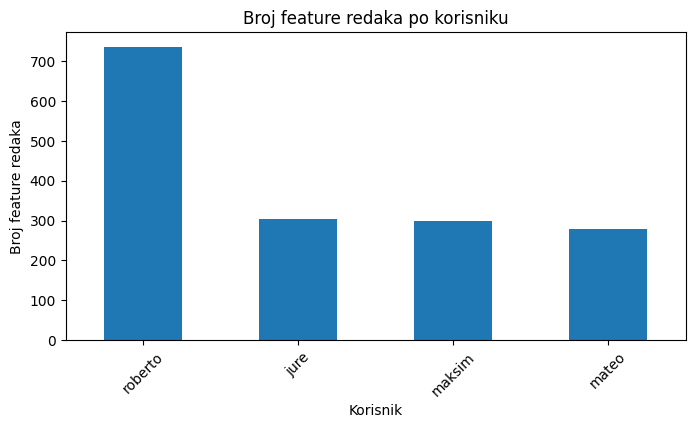

In [4]:
user_counts = df["user_id"].value_counts()

print("Broj feature redaka po korisniku:")
display(user_counts)

missing_users = [user for user in AUTHORIZED_USERS if user not in user_counts.index]
if missing_users:
    print("UPOZORENJE: Nedostaju autorizirani korisnici:", missing_users)
    print("Za korisnike koji nedostaju ne može se trenirati model.")

plt.figure(figsize=(8, 4))
user_counts.plot(kind="bar")
plt.title("Broj feature redaka po korisniku")
plt.xlabel("Korisnik")
plt.ylabel("Broj feature redaka")
plt.xticks(rotation=45)
plt.show()

Graf prikazuje da Roberto ima najviše redaka jer je prikupio najviše sirovih uzoraka tijekom faze skupljanja podataka
- svaki uzorak se dijeli na prozore od po 40 pritisaka tipki, što znači da veći broj uzoraka direktno rezultira većim broj redaka u skupu

## 5. Osnovna analiza featurea

Provjera ekstremnih vrijednosti i neuobičajenih podataka

,count,mean,std,min,25%,50%,75%,max
ht_mean,1621.0,97.894675,18.392753,58.495000,91.075000,94.157500,102.122500,161.285000
ht_std,1621.0,21.125232,13.556202,8.561067,12.013548,15.202417,28.060327,125.039199
dd_mean,1621.0,240.637493,139.420264,116.574359,181.966667,233.184615,267.058974,3215.007692
dd_std,1621.0,299.450375,714.376041,37.530177,133.642656,192.441489,267.230825,18716.152778
ud_mean,1621.0,142.738164,142.188365,0.417949,88.138462,136.800000,172.492308,3114.879487
ud_std,1621.0,300.582241,714.085833,42.050759,134.545164,190.263412,268.828303,18714.341405
typing_speed,1621.0,4.700859,1.318664,0.318717,3.803945,4.355353,5.547542,8.672275
backspace_count,1621.0,1.230722,1.784659,0.000000,0.000000,1.000000,2.000000,15.000000
backspace_ratio,1621.0,0.030768,0.044616,0.000000,0.000000,0.025000,0.050000,0.375000
total_duration,1621.0,9.482575,5.435657,4.612400,7.210400,9.184100,10.515400,125.503100


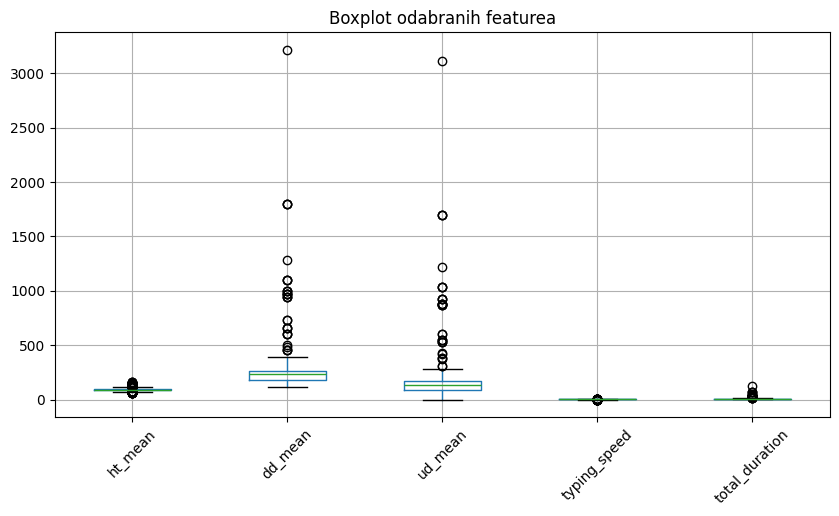

In [5]:
display(df[FEATURE_COLUMNS].describe().T)

selected_features = ["ht_mean", "dd_mean", "ud_mean", "typing_speed", "total_duration"]

plt.figure(figsize=(10, 5))
df[selected_features].boxplot()
plt.title("Boxplot odabranih featurea")
plt.xticks(rotation=45)
plt.show()

Pregledom statističkog sažetka i boxplota uočavaju se sljedeće karakteristike:
- `key_count` je točno 40 za sve prozore, što potvrđuje da podjela na prozore radi ispravno
- `ht_mean` se kreće između 58 i 161 ms, što odgovara normalnom vremenu držanja tipke
- `dd_mean` i `ud_mean` imaju maksimalne vrijednosti oko 3200 ms, što ukazuje na pauze u tipkanju unutar nekih prozora
    - takvi prozori bit će filtrirani u idućem dijelu

## 6.Izbacivanje pauza u tipkanju

Korisnici su prilikom kreiranja uzoraka uzimali pauze za vrijeme tipkanja, što je malo pokvarilo kvalitetu samih uzoraka
- takve retke potrebno je ukloniti

In [6]:
# Pravila za detekciju pauza / čudnih uzoraka
pause_mask = (
    (df["total_duration"] > 20) |
    (df["dd_mean"] > 600) |
    (df["ud_mean"] > 500) |
    (df["dd_std"] > 1000) |
    (df["ud_std"] > 1000) |
    (df["typing_speed"] < 2.0)
)

bad_rows = df[pause_mask].copy()

print("Ukupno sumnjivih redaka:", len(bad_rows))
print("Ukupno redaka:", len(df))
print("Postotak sumnjivih:", round(len(bad_rows) / len(df) * 100, 2), "%")

bad_summary = (
    bad_rows
    .groupby("user_id")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="bad_rows")
)

total_summary = (
    df
    .groupby("user_id")
    .size()
    .reset_index(name="total_rows")
)

summary = bad_summary.merge(total_summary, on="user_id", how="right")
summary["bad_rows"] = summary["bad_rows"].fillna(0).astype(int)
summary["bad_ratio"] = summary["bad_rows"] / summary["total_rows"]

summary = summary.sort_values("bad_ratio", ascending=False)

display(summary)

Ukupno sumnjivih redaka: 36
Ukupno redaka: 1621
Postotak sumnjivih: 2.22 %


,user_id,bad_rows,total_rows,bad_ratio
1,maksim,23,300,0.076667
2,mateo,11,280,0.039286
0,jure,2,305,0.006557
3,roberto,0,736,0.000000


In [7]:
pause_mask = (
    (df["total_duration"] > 20) |
    (df["dd_mean"] > 600) |
    (df["ud_mean"] > 500) |
    (df["dd_std"] > 1000) |
    (df["ud_std"] > 1000) |
    (df["typing_speed"] < 2.0)
)

df = df[~pause_mask].copy()

## 7. Pomoćne funkcije za evaluaciju

Posebno važne sigurnosne metrike: **FAR** i **FRR**
- FAR (False Acceptance Rate) - Koliko često model pogrešno prihati uljeza
- FRR (False Rejection Rate) - Koliko često model pogrešno odbije pravog korisnika

Visok FAR znači da sustav nije siguran jer propušta uljeze, dok visok FRR znači da sustav odbija pravog korisnika što je loše korisničko iskustvo
> Idealan model ima oba što bliže nuli

Budući da FAR i FRR ovise o tome koliko je model 'strog' pri prihvaćanju korisnika, uvodi se prag odlučivanja (engl. Threshold). Prag određuje od koje vjerojatnosti model prihvaća korisnika, a isprobavaju se vrijednosti od 0.30 do 0.90 i odabire onaj koji daje najbolji F1 rezultat uz što manji FAR

In [8]:
def calculate_far_frr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    frr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "far": float(far),
        "frr": float(frr),
    }


def get_positive_scores(model, X_scaled):
    classes = list(model.classes_)
    if 1 not in classes:
        raise ValueError("Model ne sadrži pozitivnu klasu 1.")
    positive_index = classes.index(1)
    return model.predict_proba(X_scaled)[:, positive_index]


def evaluate_at_threshold(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    metrics.update(calculate_far_frr(y_true, y_pred))
    return metrics, y_pred


def choose_threshold(y_true, scores):
    thresholds = np.arange(0.30, 0.91, 0.05)
    rows = []

    for threshold in thresholds:
        metrics, _ = evaluate_at_threshold(y_true, scores, threshold)
        rows.append(metrics)

    results = pd.DataFrame(rows)
    best = results.sort_values(["f1", "far"], ascending=[False, True]).iloc[0]

    return float(best["threshold"]), results

## 8. Funkcija za treniranje jednog binarnog modela

Za svakog autoriziranog korisnika trenira se zasebni binarni model koji razlikuje tog korisnika od svih ostalih

Proces treniranja odvija se u nekoliko koraka:
1) Skup podataka dijeli se na 75% za treniranje i 25% za testiranje uz stratifikaciju kako bi omjer klasa bio jednak u oba dijela
2) Značajke se normaliziraju StandardScalerom koji se uči isključivo na skupu za treniranje i potom primjenjuje na oba skupa
3) Trenira se `RandomForestClassifier` (stablo odlučivanja) s 300 stabala i uravnoteženim težinama klasa jer je broj primjera autoriziranog korisnika manji od broja primjera svih ostalih
4) Pronalazi se optimalni prag odlučivanja isprobavanjem vrijednosti od 0.30 do 0.90 i odabirom onog koji postiže najbolji F1 uz najmanji FAR
5) Model, scaler i prag spremaju se za kasniju upotrebu za predikciji

In [9]:
def train_binary_model_for_user(df, target_user, feature_columns, default_threshold=0.60):
    print("=" * 80)
    print(f"Treniranje modela za korisnika: {target_user}")
    print("=" * 80)

    X = df[feature_columns].copy()
    y = (df["user_id"] == target_user).astype(int)

    class_counts = y.value_counts().sort_index()
    print("Raspodjela klasa:")
    print(class_counts.to_string())

    if y.nunique() < 2:
        raise ValueError(
            f"Za korisnika '{target_user}' nije moguće trenirati model jer postoji samo jedna klasa."
        )

    can_stratify = class_counts.min() >= 2

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y if can_stratify else None,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        min_samples_leaf=1,
    )

    model.fit(X_train_scaled, y_train)

    scores = get_positive_scores(model, X_test_scaled)
    selected_threshold, threshold_results = choose_threshold(y_test, scores)
    threshold = selected_threshold

    metrics, y_pred = evaluate_at_threshold(y_test, scores, threshold)

    print(f"Odabrani threshold za {target_user}: {threshold:.2f}")
    print()
    print("Metrike:")
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")

    print()
    print("Classification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["svi ostali", target_user],
        zero_division=0
    ))

    return {
        "target_user": target_user,
        "model": model,
        "scaler": scaler,
        "threshold": threshold,
        "feature_columns": feature_columns,
        "X_test": X_test,
        "y_test": y_test,
        "scores": scores,
        "y_pred": y_pred,
        "metrics": metrics,
        "threshold_results": threshold_results,
    }

## 9. Treniranje modela za Juru i Matea

Funkcija za treniranje poziva se za svakog autoriziranog korisnika

Rezultati svakog modela, uključujući sam model, scaler i prag, pohranjuju se u rječnik `trained_models` za kasniju upotrebu

In [10]:
trained_models = {}

for user in AUTHORIZED_USERS:
    if user not in set(df["user_id"]):
        print(f"Preskačem korisnika '{user}' jer nema njegovih podataka u datasetu.")
        continue

    result = train_binary_model_for_user(
        df=df,
        target_user=user,
        feature_columns=FEATURE_COLUMNS,
        default_threshold=DEFAULT_THRESHOLD,
    )

    trained_models[user] = result

print("Istrenirani modeli:", list(trained_models.keys()))

Treniranje modela za korisnika: jure
Raspodjela klasa:
user_id
0    1282
1     303
Odabrani threshold za jure: 0.50

Metrike:
threshold: 0.5000
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
tn: 321
fp: 0
fn: 0
tp: 76
far: 0.0000
frr: 0.0000

Classification report:
              precision    recall  f1-score   support

  svi ostali       1.00      1.00      1.00       321
        jure       1.00      1.00      1.00        76

    accuracy                           1.00       397
   macro avg       1.00      1.00      1.00       397
weighted avg       1.00      1.00      1.00       397

Treniranje modela za korisnika: mateo
Raspodjela klasa:
user_id
0    1316
1     269
Odabrani threshold za mateo: 0.55

Metrike:
threshold: 0.5500
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
tn: 330
fp: 0
fn: 0
tp: 67
far: 0.0000
frr: 0.0000

Classification report:
              precision    recall  f1-score   support

  svi ostali       1.00      1.00      1.00       330
  

Oba modela postižu savršene rezultate s točnošću, preciznošću i odzivom od 1.0, te FAR i FRR jednakim nuli. Za Jurin model je odabran prag 0.50, dok je za Mateov odabran 0.55

Ovako visoke vrijednosti očekivane su u ovom kontekstu jer su u skupu podataka samo četiri korisnika koji međusobno dovoljno različito tipkaju da ih model lako razlikuje
- u realnom scenariju s većim brojem korisnika sličnih obrazaca tipkanja, točnost modela bi se znatno smanjila

## 10. Usporedba rezultata oba modela

Ralzika metrika istreniranih modela

In [11]:
summary_rows = []

for user, result in trained_models.items():
    row = {"user": user}
    row.update(result["metrics"])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

if not summary_df.empty:
    display(summary_df)
else:
    print("Nema istreniranih modela.")

,user,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp,far,frr
0,jure,0.50,1.0,1.0,1.0,1.0,321,0,0,76,0.0,0.0
1,mateo,0.55,1.0,1.0,1.0,1.0,330,0,0,67,0.0,0.0


## 11. Confusion matrix za svaki model

Matrica konfuzije prikazuje koliko je predikcija bilo točno, a koliko pogrešno

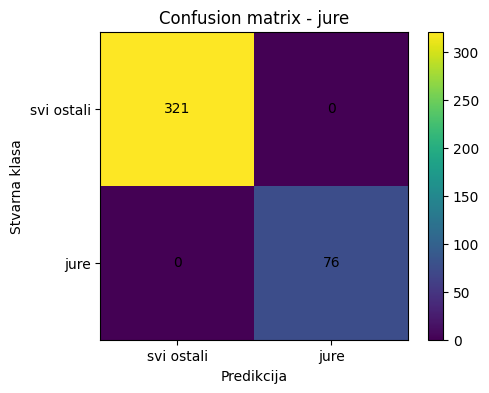

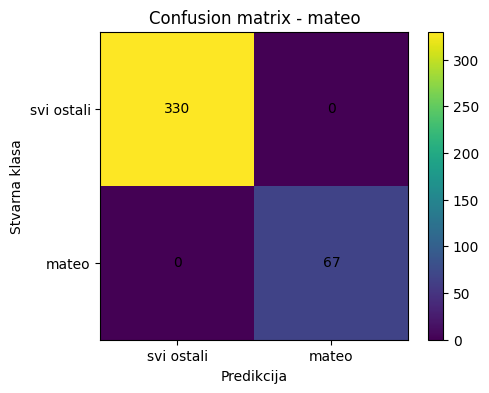

In [12]:
for user, result in trained_models.items():
    cm = confusion_matrix(result["y_test"], result["y_pred"], labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion matrix - {user}")
    plt.xlabel("Predikcija")
    plt.ylabel("Stvarna klasa")
    plt.xticks([0, 1], ["svi ostali", user])
    plt.yticks([0, 1], ["svi ostali", user])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.show()

Obje matrice pokazuju savršene rezultate bez ijedne pogrešne predikcije

Jurin model je ispravno odbio 321 uljeza i ispravno prihvatio 76 njegovih prozora, dok je za Mateov model odbijeno 330 uljeza i prihvaćeno 67 njegovih prozora

## 12. FAR i FRR po thresholdima

Ovo pomaže ručno odabrati threshold ako automatski odabir nije dobar.

,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp,far,frr,user
0,0.30,0.994962,0.974359,1.0,0.987013,319,2,0,76,0.006231,0.0,jure
1,0.35,0.994962,0.974359,1.0,0.987013,319,2,0,76,0.006231,0.0,jure
2,0.40,0.994962,0.974359,1.0,0.987013,319,2,0,76,0.006231,0.0,jure
3,0.45,0.994962,0.974359,1.0,0.987013,319,2,0,76,0.006231,0.0,jure
4,0.50,1.000000,1.000000,1.0,1.000000,321,0,0,76,0.000000,0.0,jure
5,0.55,1.000000,1.000000,1.0,1.000000,321,0,0,76,0.000000,0.0,jure
6,0.60,1.000000,1.000000,1.0,1.000000,321,0,0,76,0.000000,0.0,jure
7,0.65,1.000000,1.000000,1.0,1.000000,321,0,0,76,0.000000,0.0,jure
8,0.70,1.000000,1.000000,1.0,1.000000,321,0,0,76,0.000000,0.0,jure
9,0.75,1.000000,1.000000,1.0,1.000000,321,0,0,76,0.000000,0.0,jure


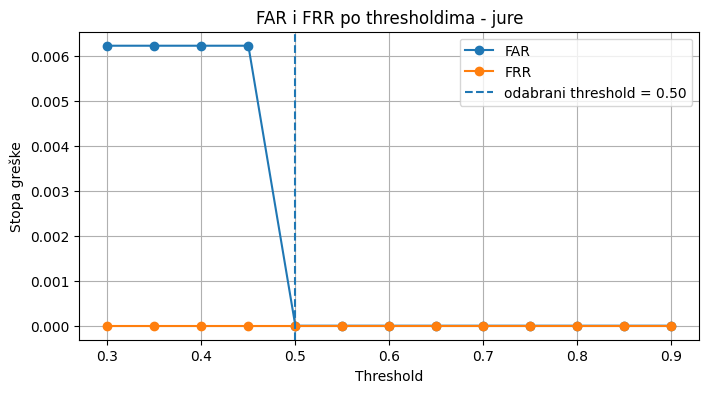

,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp,far,frr,user
0,0.30,0.994962,0.971014,1.000000,0.985294,328,2,0,67,0.006061,0.000000,mateo
1,0.35,0.994962,0.971014,1.000000,0.985294,328,2,0,67,0.006061,0.000000,mateo
2,0.40,0.997481,0.985294,1.000000,0.992593,329,1,0,67,0.003030,0.000000,mateo
3,0.45,0.997481,0.985294,1.000000,0.992593,329,1,0,67,0.003030,0.000000,mateo
4,0.50,0.997481,0.985294,1.000000,0.992593,329,1,0,67,0.003030,0.000000,mateo
5,0.55,1.000000,1.000000,1.000000,1.000000,330,0,0,67,0.000000,0.000000,mateo
6,0.60,1.000000,1.000000,1.000000,1.000000,330,0,0,67,0.000000,0.000000,mateo
7,0.65,1.000000,1.000000,1.000000,1.000000,330,0,0,67,0.000000,0.000000,mateo
8,0.70,1.000000,1.000000,1.000000,1.000000,330,0,0,67,0.000000,0.000000,mateo
9,0.75,1.000000,1.000000,1.000000,1.000000,330,0,0,67,0.000000,0.000000,mateo


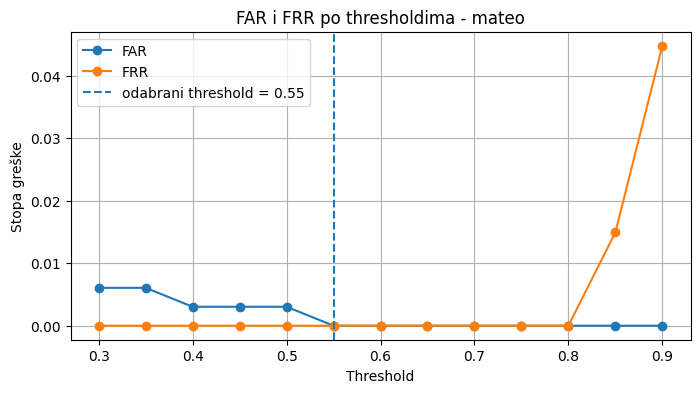

In [13]:
for user, result in trained_models.items():
    threshold_results = result["threshold_results"]

    display(threshold_results.assign(user=user))

    plt.figure(figsize=(8, 4))
    plt.plot(threshold_results["threshold"], threshold_results["far"], marker="o", label="FAR")
    plt.plot(threshold_results["threshold"], threshold_results["frr"], marker="o", label="FRR")
    plt.axvline(result["threshold"], linestyle="--", label=f"odabrani threshold = {result['threshold']:.2f}")
    plt.title(f"FAR i FRR po thresholdima - {user}")
    plt.xlabel("Threshold")
    plt.ylabel("Stopa greške")
    plt.legend()
    plt.grid(True)
    plt.show()

## 13. Raspodjela scoreova

Ukoliko je model dobar, pozitivni uzorci imaju veći score, a negativni niži score

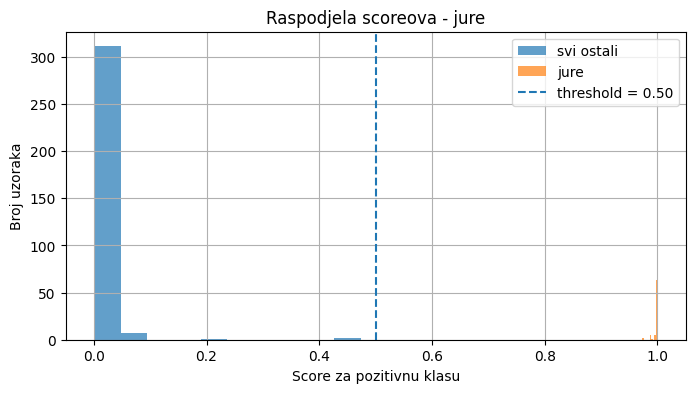

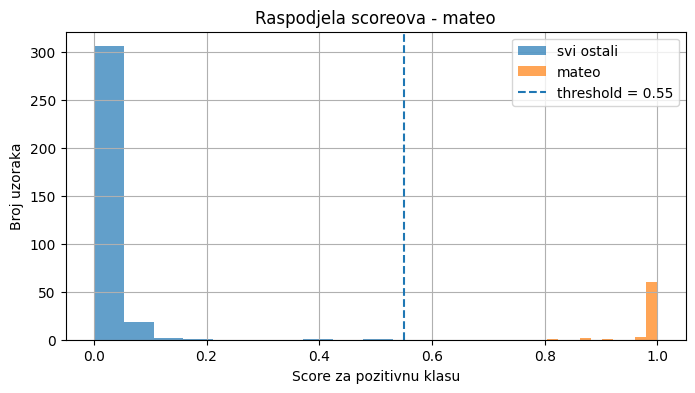

In [14]:
for user, result in trained_models.items():
    score_df = pd.DataFrame({
        "score": result["scores"],
        "label": result["y_test"].values,
    })

    plt.figure(figsize=(8, 4))
    score_df[score_df["label"] == 0]["score"].hist(alpha=0.7, label="svi ostali")
    score_df[score_df["label"] == 1]["score"].hist(alpha=0.7, label=user)
    plt.axvline(result["threshold"], linestyle="--", label=f"threshold = {result['threshold']:.2f}")
    plt.title(f"Raspodjela scoreova - {user}")
    plt.xlabel("Score za pozitivnu klasu")
    plt.ylabel("Broj uzoraka")
    plt.legend()
    plt.show()

> Plavi stupci predstavljaju uljeze, narančasti autoriziranog korisnika, a isprekidana linija označava odabrani prag

Na oba grafa vidljivo je jasno razdvajanje između klasa

Uzorci uljeza gomilaju se oko vrijednosti 0, dok uzorci autoriziranog korisnika imaju score blizu 1

Prag je postavljen između te dvije grupe pa nema preklapanja, što potvrđuje zašto su FAR i FRR jednaki nuli

## 14. Važnost značajki za svaki model

Ovo pokazuje koje značajke su bile najkorisnije za pojedini model

Feature importance - jure


,feature,importance
0,ht_mean,0.507395
1,ht_std,0.277407
4,ud_mean,0.084208
2,dd_mean,0.025208
9,total_duration,0.025019
6,typing_speed,0.020652
3,dd_std,0.020481
5,ud_std,0.020358
8,backspace_ratio,0.010336
7,backspace_count,0.008935


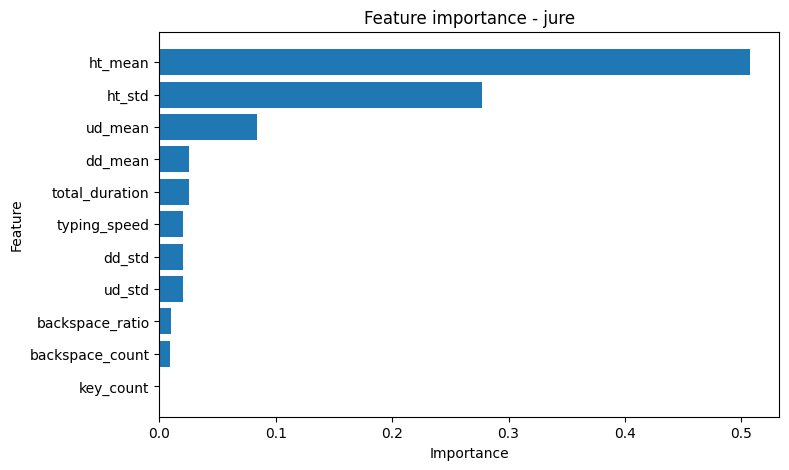

Feature importance - mateo


,feature,importance
1,ht_std,0.344451
0,ht_mean,0.293638
4,ud_mean,0.099825
9,total_duration,0.065697
2,dd_mean,0.057336
6,typing_speed,0.050268
3,dd_std,0.037212
5,ud_std,0.034804
7,backspace_count,0.008644
8,backspace_ratio,0.008125


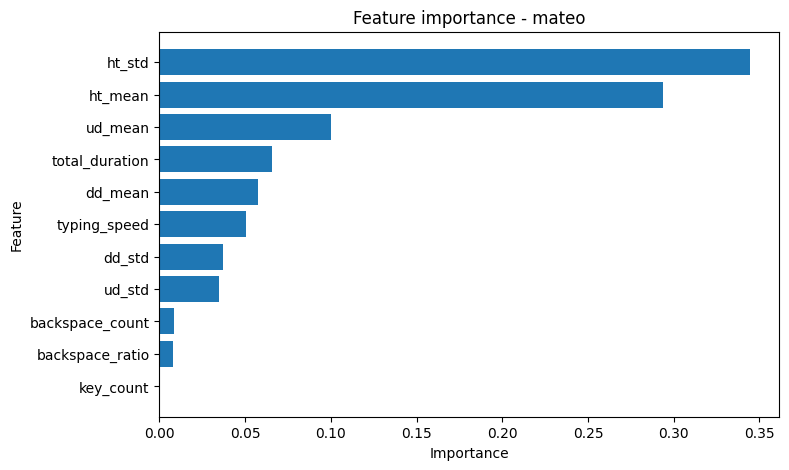

In [15]:
for user, result in trained_models.items():
    model = result["model"]

    importance_df = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

    print(f"Feature importance - {user}")
    display(importance_df)

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.title(f"Feature importance - {user}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.show()

U oba modela dominiraju značajke vezane uz vrijeme držanja tipke, no redoslijed se razlikuje:
- Jure:
    - najvažnija ht_mean (0.51), a zatim ht_std (0.28)
- Mateo:
    - najvažnija ht_std (0.34) pa ht_mean (0.29)

Model jednog korisnika prepoznaje više po prosječnom vremenu držanja tipke, dok drugog korisnika po varijablinosti tog vremena

Različite najvažnije značajke dokazuju upravo to da svaki pojedinac ima sspecifičnu dinamiku tipkanja te razlikuju od ostalih u odredenim dijelovima

## 15. Spremanje modela

Spremanje modele, scalera i thresholda za svakog korisnika

In [16]:
if not trained_models:
    raise ValueError("Nema istreniranih modela za spremanje.")

for user, result in trained_models.items():
    model_path = MODELS_DIR / f"{user}_model.pkl"
    scaler_path = MODELS_DIR / f"{user}_scaler.pkl"
    threshold_path = MODELS_DIR / f"{user}_threshold.json"

    joblib.dump(result["model"], model_path)
    joblib.dump(result["scaler"], scaler_path)

    with threshold_path.open("w", encoding="utf-8") as f:
        json.dump({"threshold": result["threshold"]}, f, ensure_ascii=False, indent=2)

    print(f"Spremljeno za {user}:")
    print(" ", model_path)
    print(" ", scaler_path)
    print(" ", threshold_path)

feature_columns_path = MODELS_DIR / "feature_columns.json"
with feature_columns_path.open("w", encoding="utf-8") as f:
    json.dump(FEATURE_COLUMNS, f, ensure_ascii=False, indent=2)

print("Spremljeno:")
print(" ", feature_columns_path)

Spremljeno za jure:
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/jure_model.pkl
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/jure_scaler.pkl
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/jure_threshold.json
Spremljeno za mateo:
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/mateo_model.pkl
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/mateo_scaler.pkl
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/mateo_threshold.json
Spremljeno:
  /mnt/c/Users/jurej/Desktop/keystroke-shit/models/feature_columns.json


## 16. Spremanje rezultata evaluacije

Rezultati se spremaju u `docs/model_results.csv`.

In [17]:
results_path = RESULTS_DIR / "model_results.csv"

if not summary_df.empty:
    summary_df.to_csv(results_path, index=False, encoding="utf-8")
    print("Spremljeni rezultati:", results_path)
else:
    print("Nema rezultata za spremanje.")

Spremljeni rezultati: /mnt/c/Users/jurej/Desktop/keystroke-shit/docs/model_results.csv
